In [8]:
# Creating revenue simulation 
# Loading cleaned dataset and computing 2025 revenue scenarios using
# each region and category's actual 2022-2024 compound annual growth rate
# (CAGR). All inputs are derived directly from the cleaned dataset and no
# figures are assumed.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Global_Sales_Performance_Cleaned.csv")

region_piv = df.pivot_table(index="Region", columns="Year", values="Total_Revenue", aggfunc="sum")
cat_piv = df.pivot_table(index="Product_Category", columns="Year", values="Total_Revenue", aggfunc="sum")

def cagr(v0, v1, periods):
    return (v1 / v0) ** (1 / periods) - 1

In [2]:
# Calculating each region's 2022-2024 CAGR and the baseline 2025 projection
# if current trends continue unchanged.

region_cagr = {r: cagr(region_piv.loc[r, 2022], region_piv.loc[r, 2024], 2) for r in region_piv.index}
total_2024 = region_piv[2024].sum()

baseline_2025 = {r: region_piv.loc[r, 2024] * (1 + region_cagr[r]) for r in region_piv.index}
baseline_total_2025 = sum(baseline_2025.values())

print("Regional 2022-2024 CAGR:")
for r, c in region_cagr.items():
    print(f"  {r}: {c*100:.2f}%")
print(f"\nBaseline total 2025 (trend continues): ${baseline_total_2025:,.0f}")

Regional 2022-2024 CAGR:
  Asia-Pacific: -1.60%
  Europe: -7.37%
  Latin America: -17.13%
  Middle East: 7.44%
  North America: -3.18%

Baseline total 2025 (trend continues): $87,264,324


In [3]:
# Scenario: Latin America's decline is stabilized (2024 level)
# instead of continuing current downward trend.

latam_stabilized_2025 = dict(baseline_2025)
latam_stabilized_2025["Latin America"] = region_piv.loc["Latin America", 2024]
latam_revenue_protected = sum(latam_stabilized_2025.values()) - baseline_total_2025

print(f"Latin America stabilized total 2025: ${sum(latam_stabilized_2025.values()):,.0f}")
print(f"Revenue protected vs. baseline: ${latam_revenue_protected:,.0f}")

Latin America stabilized total 2025: $89,796,897
Revenue protected vs. baseline: $2,532,573


In [4]:
# Scenario: every region matches the Middle East's CAGR, the strongest
# performer in the dataset.

me_cagr = region_cagr["Middle East"]
me_led_2025 = {r: region_piv.loc[r, 2024] * (1 + me_cagr) for r in region_piv.index}
me_led_total_2025 = sum(me_led_2025.values())
me_upside = me_led_total_2025 - baseline_total_2025

print(f"Middle East CAGR: {me_cagr*100:.2f}%")
print(f"ME-led recovery total 2025: ${me_led_total_2025:,.0f}")
print(f"Upside vs. baseline: ${me_upside:,.0f}")

Middle East CAGR: 7.44%
ME-led recovery total 2025: $97,254,644
Upside vs. baseline: $9,990,320


In [5]:
# Category diversification scenario: shifting 10% of total revenue mix
# away from the declining, overconcentrated Raw Materials category into
# the three categories with positive 2022-2024 growth.

cat_cagr = {c: cagr(cat_piv.loc[c, 2022], cat_piv.loc[c, 2024], 2) for c in cat_piv.index}
growing_cats = ["Apparel & Footwear", "Automotive Parts", "Consumer Goods"]
growing_total_2024 = sum(cat_piv.loc[c, 2024] for c in growing_cats)
shift_amount = total_2024 * 0.10

baseline_cat_2025 = {c: cat_piv.loc[c, 2024] * (1 + cat_cagr[c]) for c in cat_piv.index}
baseline_cat_total_2025 = sum(baseline_cat_2025.values())

diversified_2024 = dict(cat_piv[2024])
diversified_2024["Raw Materials"] -= shift_amount
for c in growing_cats:
    diversified_2024[c] += shift_amount * (cat_piv.loc[c, 2024] / growing_total_2024)

diversified_cat_2025 = {c: diversified_2024[c] * (1 + cat_cagr[c]) for c in cat_piv.index}
diversified_total_2025 = sum(diversified_cat_2025.values())
diversification_upside = diversified_total_2025 - baseline_cat_total_2025

print(f"Baseline total 2025 (no diversification): ${baseline_cat_total_2025:,.0f}")
print(f"Diversified total 2025: ${diversified_total_2025:,.0f}")
print(f"Diversification upside: ${diversification_upside:,.0f}")

Baseline total 2025 (no diversification): $86,530,927
Diversified total 2025: $87,334,893
Diversification upside: $803,965


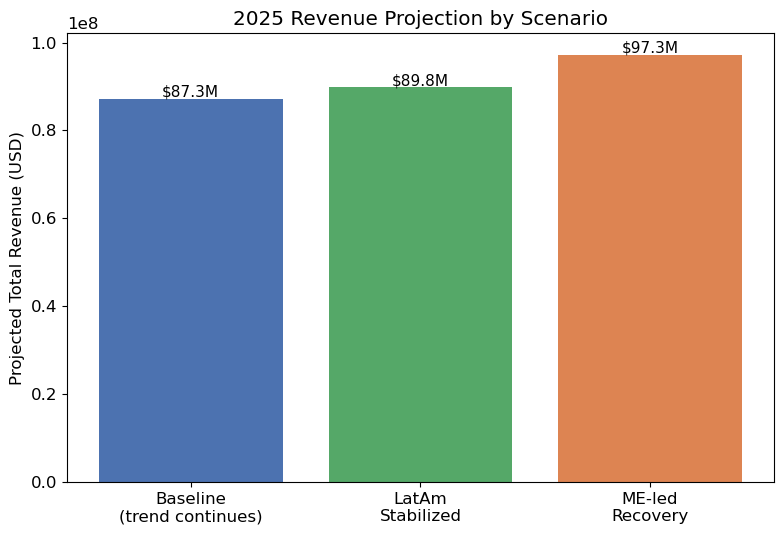

In [6]:
# Visualizing the regional scenarios side by side.

plt.rcParams["font.size"] = 12
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = ["Baseline\n(trend continues)", "LatAm\nStabilized", "ME-led\nRecovery"]
values = [baseline_total_2025, sum(latam_stabilized_2025.values()), me_led_total_2025]
colors = ["#4C72B0", "#55A868", "#DD8452"]
bars = ax.bar(labels, values, color=colors)
ax.set_title("2025 Revenue Projection by Scenario")
ax.set_ylabel("Projected Total Revenue (USD)")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 500000, f"${val/1e6:.1f}M", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

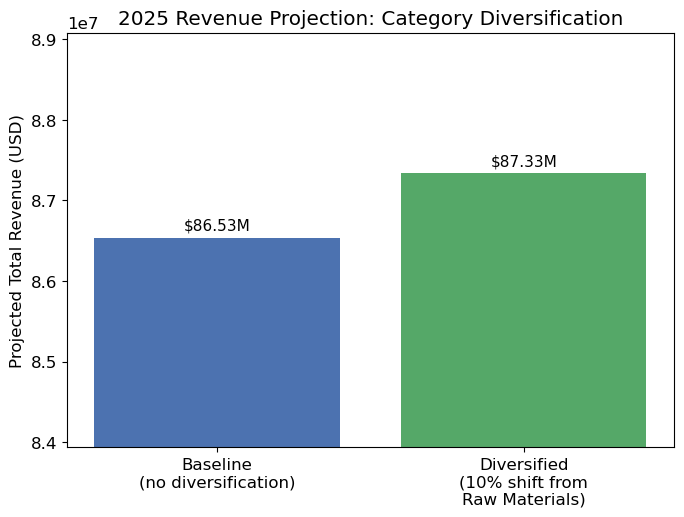

In [7]:
# Visualizing category diversification scenario.

fig, ax = plt.subplots(figsize=(7, 5.5))
labels2 = ["Baseline\n(no diversification)", "Diversified\n(10% shift from\nRaw Materials)"]
values2 = [baseline_cat_total_2025, diversified_total_2025]
bars2 = ax.bar(labels2, values2, color=["#4C72B0", "#55A868"])
ax.set_title("2025 Revenue Projection: Category Diversification")
ax.set_ylabel("Projected Total Revenue (USD)")
ax.set_ylim(min(values2) * 0.97, max(values2) * 1.02)
for bar, val in zip(bars2, values2):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 100000, f"${val/1e6:.2f}M", ha="center", fontsize=11)
plt.tight_layout()
plt.show()